In [2]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/dataset_retinopathy/aptos2019-blindness-detection"

In [6]:
import os

print(os.listdir(dataset_path))

['sample_submission.csv', 'test.csv', 'train.csv', '.DS_Store', 'train_images', 'test_images']


In [7]:
import pandas as pd

csv_path = dataset_path + "/train.csv"

data = pd.read_csv(csv_path)

print(data.head())
print(data.columns)
print(data.shape)

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Index(['id_code', 'diagnosis'], dtype='object')
(3662, 2)


In [8]:
import pandas as pd

dataset_path = "/content/drive/MyDrive/dataset_retinopathy/aptos2019-blindness-detection"

data = pd.read_csv(dataset_path + "/train.csv")

print(data.head())
print(data.columns)
print(data.shape)

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Index(['id_code', 'diagnosis'], dtype='object')
(3662, 2)


In [9]:
print(data["diagnosis"].value_counts())

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [10]:
# A1: Calculate Entropy

import math

def calculate_entropy(values):
    total_values = len(values)

    value_counts = {}

    for value in values:
        if value in value_counts:
            value_counts[value] = value_counts[value] + 1
        else:
            value_counts[value] = 1

    entropy = 0

    for count in value_counts.values():
        probability = count / total_values
        entropy = entropy - probability * math.log2(probability)

    return entropy


entropy_value = calculate_entropy(data["diagnosis"])

print("Entropy of the dataset:", entropy_value)

Entropy of the dataset: 1.8649647110062533


In [11]:
# A2: Calculate Gini Index

def calculate_gini(values):
    total_values = len(values)

    value_counts = {}

    for value in values:
        if value in value_counts:
            value_counts[value] = value_counts[value] + 1
        else:
            value_counts[value] = 1

    gini = 1

    for count in value_counts.values():
        probability = count / total_values
        gini = gini - probability * probability

    return gini


gini_value = calculate_gini(data["diagnosis"])

print("Gini Index of the dataset:", gini_value)

Gini Index of the dataset: 0.6631530343519478


In [12]:
# A3

import os
import numpy as np
from PIL import Image
import pandas as pd

In [13]:
image_folder = dataset_path + "/train_images"

print(os.listdir(image_folder)[:5])

['4beeca5cc859.png', '4bd5d0b30198.png', '4c17e85686f0.png', '4c60f6fcea75.png', '4c6c5a1bf5ab.png']


In [14]:
def extract_image_features(image_path):
    image = Image.open(image_path).convert("RGB")

    image_array = np.array(image)

    average_red = image_array[:, :, 0].mean()
    average_green = image_array[:, :, 1].mean()
    average_blue = image_array[:, :, 2].mean()

    brightness = (
        average_red + average_green + average_blue
    ) / 3

    return (
        average_red,
        average_green,
        average_blue,
        brightness
    )

In [20]:
feature_rows = []

for i in range(500):
    image_name = data["id_code"][i] + ".png"
    image_path = image_folder + "/" + image_name

    if os.path.exists(image_path):
        red, green, blue, brightness = extract_image_features(image_path)

        row = [
            red,
            green,
            blue,
            brightness,
            data["diagnosis"][i]
        ]

        feature_rows.append(row)

feature_data = pd.DataFrame(
    feature_rows,
    columns=[
        "average_red",
        "average_green",
        "average_blue",
        "brightness",
        "diagnosis"
    ]
)

print(feature_data.head())
print(feature_data.shape)

   average_red  average_green  average_blue  brightness  diagnosis
0   133.362008      71.355011     32.730034   79.149018          0
1   132.605161      63.289517      3.460063   66.451580          0
2   128.910883      64.094578      4.922295   65.975918          0
3   137.822041      67.262607      2.773326   69.285991          0
4    67.249452      39.927959     23.305833   43.494415          0
(167, 5)


In [25]:
#showa how many images belong to each diagnosis class
print(feature_data["diagnosis"].value_counts())

diagnosis
0    135
2     21
4      6
1      4
3      1
Name: count, dtype: int64


In [21]:
#a3
def calculate_information_gain(feature_values, target_values, bins=4):
    total_entropy = calculate_entropy(target_values)

    minimum = min(feature_values)
    maximum = max(feature_values)

    bin_width = (maximum - minimum) / bins

    groups = []

    for i in range(bins):
        group = []

        lower_limit = minimum + i * bin_width
        upper_limit = minimum + (i + 1) * bin_width

        for j in range(len(feature_values)):
            value = feature_values[j]

            if i == bins - 1:
                if value >= lower_limit and value <= upper_limit:
                    group.append(target_values[j])
            else:
                if value >= lower_limit and value < upper_limit:
                    group.append(target_values[j])

        groups.append(group)

    weighted_entropy = 0

    for group in groups:
        if len(group) > 0:
            weight = len(group) / len(target_values)
            weighted_entropy = weighted_entropy + weight * calculate_entropy(group)

    information_gain = total_entropy - weighted_entropy

    return information_gain

In [22]:
def find_root_feature(feature_data):
    feature_names = [
        "average_red",
        "average_green",
        "average_blue",
        "brightness"
    ]

    target_values = feature_data["diagnosis"].tolist()

    best_feature = ""
    best_gain = -1

    for feature_name in feature_names:
        feature_values = feature_data[feature_name].tolist()

        gain = calculate_information_gain(
            feature_values,
            target_values
        )

        print(feature_name, "Information Gain:", gain)

        if gain > best_gain:
            best_gain = gain
            best_feature = feature_name

    return best_feature, best_gain

In [23]:
root_feature, information_gain = find_root_feature(feature_data)

print("Root Feature:", root_feature)
print("Highest Information Gain:", information_gain)

average_red Information Gain: 0.15041320871699515
average_green Information Gain: 0.14948139799475846
average_blue Information Gain: 0.047042089323219516
brightness Information Gain: 0.17157309148342859
Root Feature: brightness
Highest Information Gain: 0.17157309148342859


In [26]:
#a4
import numpy as np

def bin_feature(values, binning_type="equal_width", number_of_bins=4):
    """
    Converts continuous values into categorical bins.

    values: List of continuous values
    binning_type: "equal_width" or "frequency"
    number_of_bins: Number of bins to create
    """

    values = np.array(values)

    # Equal-width binning
    if binning_type == "equal_width":

        minimum = min(values)
        maximum = max(values)

        bin_width = (maximum - minimum) / number_of_bins

        binned_values = []

        for value in values:
            if value == maximum:
                bin_number = number_of_bins - 1
            else:
                bin_number = int((value - minimum) / bin_width)

            binned_values.append(bin_number)

    # Frequency binning
    elif binning_type == "frequency":

        sorted_values = sorted(values)

        binned_values = []

        for value in values:
            rank = sorted_values.index(value)
            bin_number = int(rank * number_of_bins / len(values))

            if bin_number >= number_of_bins:
                bin_number = number_of_bins - 1

            binned_values.append(bin_number)

    return binned_values

In [27]:
brightness_values = feature_data["brightness"].tolist()

equal_width_values = bin_feature(
    brightness_values,
    "equal_width",
    4
)

print("Equal-width bins:")
print(equal_width_values[:20])

Equal-width bins:
[2, 2, 1, 2, 0, 0, 2, 0, 1, 1, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2]


In [28]:
frequency_values = bin_feature(
    brightness_values,
    "frequency",
    4
)

print("Frequency bins:")
print(frequency_values[:20])

Frequency bins:
[3, 2, 1, 2, 0, 0, 2, 0, 1, 1, 3, 1, 0, 1, 2, 3, 1, 2, 3, 2]


In [29]:
default_values = bin_feature(brightness_values)

print("Default bins:")
print(default_values[:20])

Default bins:
[2, 2, 1, 2, 0, 0, 2, 0, 1, 1, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2]


In [35]:
# A5: Build a simple Decision Tree module

def find_majority_class(values):
    class_counts = {}

    for value in values:
        if value in class_counts:
            class_counts[value] = class_counts[value] + 1
        else:
            class_counts[value] = 1

    majority_class = max(
        class_counts,
        key=class_counts.get
    )

    return majority_class


def build_decision_tree(data, target_column):
    # Find the root feature using Information Gain
    root_feature, information_gain = find_root_feature(data)

    # Get the values of the root feature
    feature_values = list(data[root_feature])

    # Convert continuous values into four bins
    binned_values = bin_feature(
        feature_values,
        "equal_width",
        4
    )

    target_values = list(data[target_column])

    tree = {}

    # Find the different bins
    unique_bins = set(binned_values)

    # Find the majority class in each bin
    for bin_value in unique_bins:
        subset_targets = []

        for i in range(len(binned_values)):
            if binned_values[i] == bin_value:
                subset_targets.append(target_values[i])

        majority_class = find_majority_class(subset_targets)

        tree[bin_value] = majority_class

    return root_feature, information_gain, tree

# Main program

root_feature, information_gain, tree = build_decision_tree(
    feature_data,
    "diagnosis"
)

print("Root Feature:", root_feature)
print("Information Gain:", information_gain)

print("\nDecision Tree:")

for bin_value in tree:
    print("Bin", bin_value, "-> Diagnosis", tree[bin_value])

average_red Information Gain: 0.15041320871699515
average_green Information Gain: 0.14948139799475846
average_blue Information Gain: 0.047042089323219516
brightness Information Gain: 0.17157309148342859
Root Feature: brightness
Information Gain: 0.17157309148342859

Decision Tree:
Bin 0 -> Diagnosis 0
Bin 1 -> Diagnosis 0
Bin 2 -> Diagnosis 0
Bin 3 -> Diagnosis 2


In [37]:
#a6
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Select the input features
X = feature_data[
    [
        "average_red",
        "average_green",
        "average_blue",
        "brightness"
    ]
]

# Select the target column
y = feature_data["diagnosis"]

# Create the Decision Tree classifier
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Train the model
model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

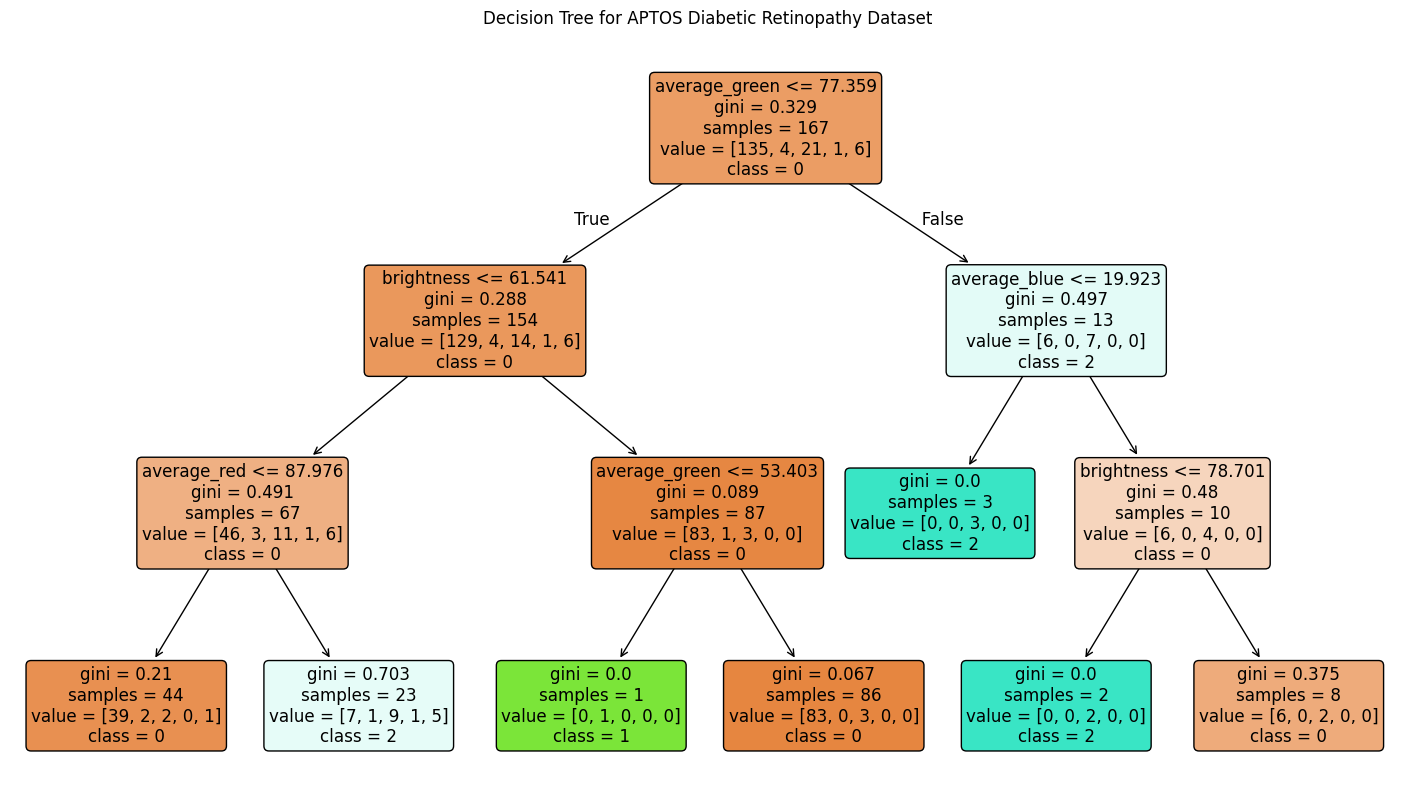

In [38]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["0", "1", "2", "3", "4"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for APTOS Diabetic Retinopathy Dataset")
plt.show()

In [41]:
#a7
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

X = feature_data[
    [
        "brightness",
        "average_red"
    ]
]

y = feature_data["diagnosis"]

#train the decision tree classifier
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [42]:
# Find the minimum and maximum values of both features
x_min = X["brightness"].min() - 1
x_max = X["brightness"].max() + 1

y_min = X["average_red"].min() - 1
y_max = X["average_red"].max() + 1

# Create a grid of points
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

# Predict the class for every point in the grid
grid_predictions = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Reshape predictions to match the grid
grid_predictions = grid_predictions.reshape(xx.shape)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


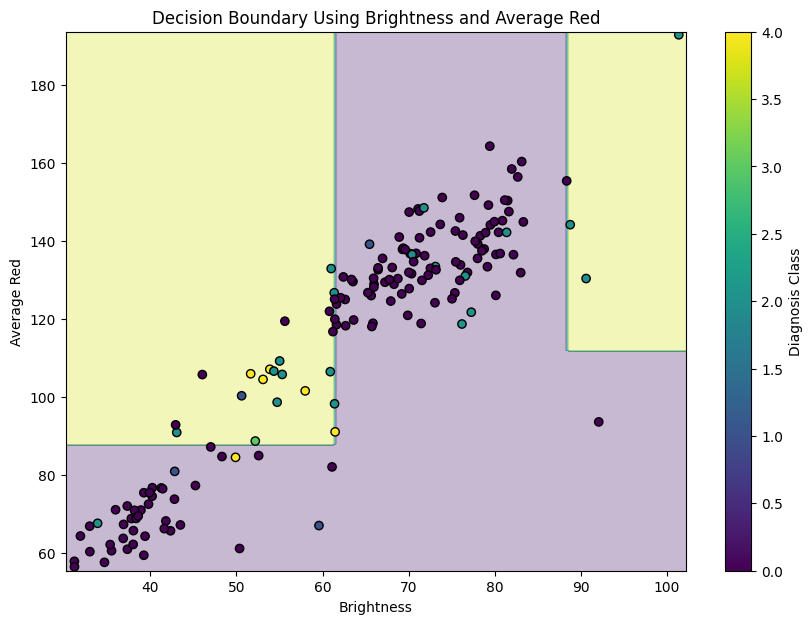

In [43]:
plt.figure(figsize=(10, 7))

# Draw the decision regions
plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.3
)

# Draw the actual data points
scatter = plt.scatter(
    X["brightness"],
    X["average_red"],
    c=y,
    edgecolor="black"
)

plt.xlabel("Brightness")
plt.ylabel("Average Red")
plt.title("Decision Boundary Using Brightness and Average Red")

plt.colorbar(scatter, label="Diagnosis Class")

plt.show()

In [49]:
#a8
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)
#Define the hyperparameter values
parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#Apply GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X, y)

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)


best_model = grid_search.best_estimator_

print("Best Decision Tree Model:")
print(best_model)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Accuracy:
0.8324420677361853
Best Decision Tree Model:
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=4,
                       random_state=42)
